# Use Case: Heatwave Evolution Analysis

This notebook demonstrates how to use `earthkit-climate` to analyze whether heatwaves are becoming more frequent and longer over time. We will compute heatwave indices from daily minimum (`tasmin`) and maximum (`tasmax`) temperature data and compare different decades.

We'll use:
- **`heat_wave_frequency`**: Number of heatwaves in a given period.
- **`heat_wave_max_length`**: Maximum length of a heatwave in a given period.

A heatwave is defined as a period where both the daily **minimum** temperature exceeds a threshold (e.g., 22°C) **and** the daily **maximum** temperature exceeds another threshold (e.g., 30°C) for a minimum number of consecutive days.

The analysis will involve loading CMIP6 data, computing indices, aggregating results by decade, and visualizing spatial anomalies.

In [7]:
import warnings

import earthkit.data as ekd
import earthkit.plots as ekp
import numpy

from earthkit.climate.indicators.temperature import (
    heat_wave_frequency,
    heat_wave_max_length,
)

warnings.filterwarnings("ignore")

## Loading Data

We will load historical daily minimum (`tasmin`) and maximum (`tasmax`) temperature data from the ACCESS-CM2 CMIP6 model.

In [8]:
tasmax_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
)
ds_tasmax = tasmax_hist.to_xarray()

tasmin_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
)
ds_tasmin = tasmin_hist.to_xarray()

## Computing Heatwave Indices

We define a heatwave as a period of at least 5 consecutive days where:
- The daily **minimum** temperature exceeds **22°C** (`thresh_tasmin`)
- The daily **maximum** temperature exceeds **30°C** (`thresh_tasmax`)

Both conditions must be satisfied simultaneously.

In [9]:
thresh_tasmin = "22.0 degC"
thresh_tasmax = "30 degC"
window = 5

# Compute annual heatwave frequency
hwf = heat_wave_frequency(
    ds_tasmin.tasmin,
    ds_tasmax.tasmax,
    thresh_tasmin=thresh_tasmin,
    thresh_tasmax=thresh_tasmax,
    window=window,
    freq="YS"
)

# Compute annual maximum heatwave length
hwl = heat_wave_max_length(
    ds_tasmin.tasmin,
    ds_tasmax.tasmax,
    thresh_tasmin=thresh_tasmin,
    thresh_tasmax=thresh_tasmax,
    window=window,
    freq="YS"
)

# xclim sets units="1" for dimensionless indices; replace with "dimensionless"
if hwf.attrs.get("units") == "1":
    hwf.attrs["units"] = "dimensionless"


## Decadal Aggregation and Anomalies

We compare the 1980s (1980-1989) with the 2000s (2000-2009) to see how heatwaves have evolved.

In [10]:
hwf_1980s = hwf.sel(time=slice("1980", "1989")).mean(dim="time", keep_attrs=True)
hwf_2000s = hwf.sel(time=slice("2000", "2009")).mean(dim="time", keep_attrs=True)
hwf_anomaly = hwf_2000s - hwf_1980s
hwf_anomaly.attrs.update(hwf.attrs)

hwl_1980s = hwl.sel(time=slice("1980", "1989")).mean(dim="time", keep_attrs=True)
hwl_2000s = hwl.sel(time=slice("2000", "2009")).mean(dim="time", keep_attrs=True)
hwl_anomaly = hwl_2000s - hwl_1980s
hwl_anomaly.attrs.update(hwl.attrs)

## Visualization

Let's visualize the anomalies in heatwave frequency and length.

ValueError: No points given

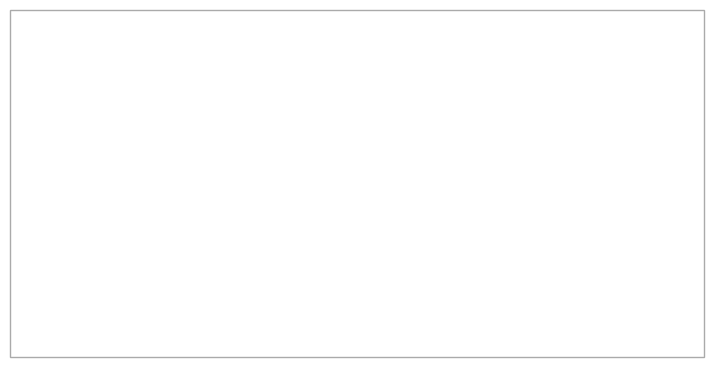

In [ ]:
figure = ekp.Figure(
    rows=1, columns=2, size=(14, 5)
)

indices = {
    "HWF Anomaly": hwf_anomaly,
    "HWL Anomaly": hwl_anomaly,
}

cmaps = {
    "HWF Anomaly": "RdBu_r",
    "HWL Anomaly": "RdBu_r",
}

for col, (name, data) in enumerate(indices.items()):
    # Explicitly set units for the style to avoid inference issues
    style = ekp.styles.Style(colors=cmaps[name])

    map_plot = figure.add_map(row=0, column=col)
    # Use quickplot via Map object
    map_plot.quickplot(data, style=style)

    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.title(f"{name} (2000s minus 1980s)")
    map_plot.legend(location="right")

figure.show()